# Workshop 3 Report Notebook

## Core Question
**What variables are most associated with penguin body mass?**

This notebook mirrors Workshop 3 and is structured like a short report. Run cells top-to-bottom.

In [1]:
!pip install pandas matplotlib

## 1) Load and Inspect Data

Goal: load data, inspect columns/types, and identify candidate predictors for `body_mass_g`.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

penguins = pd.read_csv("penguins.csv")
print("Rows:", len(penguins))
print("\nColumns:")
print(penguins.columns.tolist())
print("\nData types:")
print(penguins.dtypes)
print("\nMissing values per column:")
print(penguins.isna().sum())

candidate_predictors = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "species",
    "sex",
    "island",
    "year",
]
print("\nCandidate predictors:", candidate_predictors)

Rows: 344

Columns:
['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

Data types:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Candidate predictors: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species', 'sex', 'island', 'year']


## 2) Clean Data

Goal: remove rows with missing values in body mass and key predictors, then report retained sample size.

In [3]:
cols_needed = [
    "body_mass_g",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "species",
    "sex",
    "island",
    "year",
]

penguins_clean = penguins.dropna(subset=cols_needed).copy()
before = len(penguins)
after = len(penguins_clean)
print("Before:", before, "| After:", after)
print("Retained (%):", round(after / before * 100, 1))

Before: 344 | After: 333
Retained (%): 96.8


## 3) Association Tables

Goal: produce species-level summary and a ranked numeric association table with `body_mass_g`.

In [4]:
species_summary = (
    penguins_clean.groupby("species")
    .agg(
        n=("body_mass_g", "count"),
        avg_body_mass_g=("body_mass_g", "mean"),
    )
    .round(1)
)

num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "year", "body_mass_g"]
corr_to_mass = (
    penguins_clean[num_cols]
    .corr(numeric_only=True)["body_mass_g"]
    .drop("body_mass_g")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_body_mass_g")
)

print("Species summary:")
display(species_summary)

print("Ranked numeric associations with body_mass_g (absolute strength):")
display(corr_to_mass.round(3))

Species summary:


,n,avg_body_mass_g
species,,
Adelie,146,3706.2
Chinstrap,68,3733.1
Gentoo,119,5092.4


Ranked numeric associations with body_mass_g (absolute strength):


,corr_with_body_mass_g
flipper_length_mm,0.873
bill_length_mm,0.589
bill_depth_mm,-0.472
year,0.022


## 4) Visual Evidence

Goal: inspect body mass relationship with flipper length and compare body mass across species.

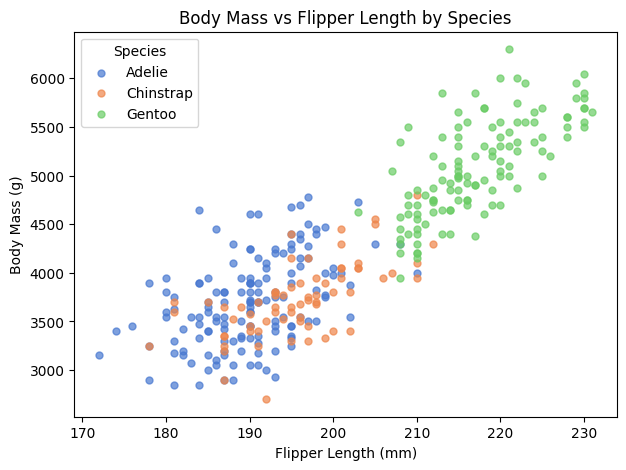

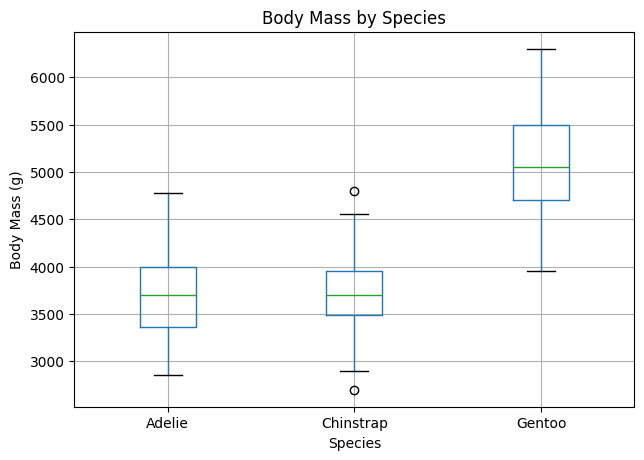

In [5]:
species_colors = {
    "Adelie": "#4878d0",
    "Chinstrap": "#ee854a",
    "Gentoo": "#6acc65",
}

fig, ax = plt.subplots(figsize=(7, 5))
for sp in ["Adelie", "Chinstrap", "Gentoo"]:
    sub = penguins_clean[penguins_clean["species"] == sp]
    ax.scatter(
        sub["flipper_length_mm"],
        sub["body_mass_g"],
        c=species_colors[sp],
        label=sp,
        alpha=0.7,
        s=25,
    )

ax.set_title("Body Mass vs Flipper Length by Species")
ax.set_xlabel("Flipper Length (mm)")
ax.set_ylabel("Body Mass (g)")
ax.legend(title="Species")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
penguins_clean.boxplot(column="body_mass_g", by="species", ax=ax)
ax.set_title("Body Mass by Species")
ax.set_xlabel("Species")
ax.set_ylabel("Body Mass (g)")
plt.suptitle("")
plt.show()